
# Linear Regression Assumptions

## 1. Linearity

The relationship between the independent variables and the dependent variable is linear.

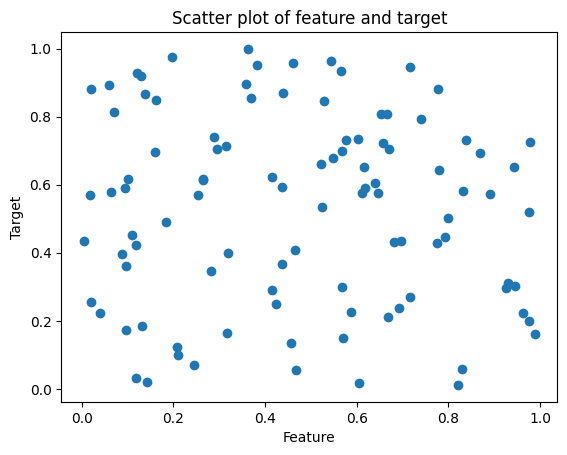

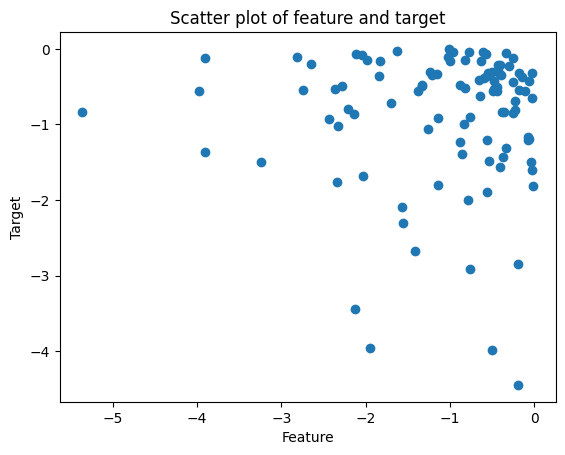

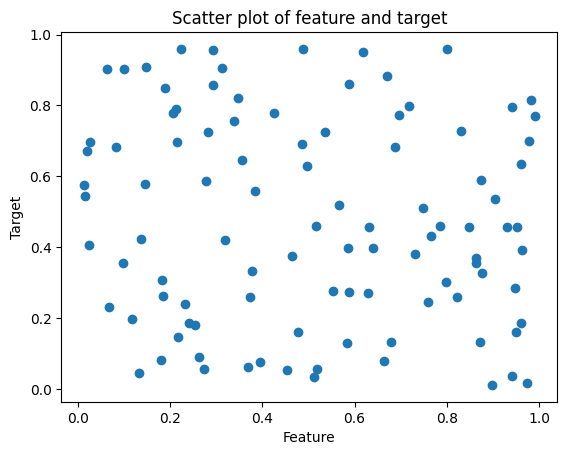

Before transformation
0.05016568888729814
0.08365163596480693


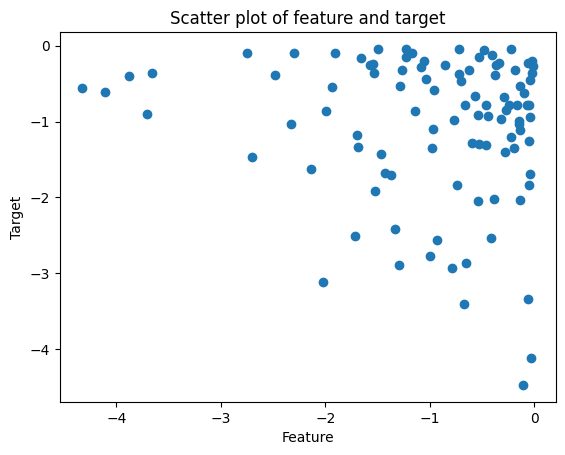

After transformation
-1.5486156416319394
-1.3740581675970422


In [ ]:
# code to check linearity of linear regression assumptions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
np.random.seed(0)
# create a synthetic dataset which shows linearity
df = pd.DataFrame({
    'feature': np.random.rand(100),
    'target': np.random.rand(100),
})
    
# Scatter plot
plt.scatter(df['feature'], df['target'])
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Scatter plot of feature and target')
plt.show()



# Resolution:
# Apply non-linear transformations (log, square root, polynomial)
# Apply transformation to convert it to normal distribution
df['feature'] = np.log(df['feature'])
df['target'] = np.log(df['target'])
# Scatter plot
plt.scatter(df['feature'], df['target'])
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Scatter plot of feature and target')
plt.show()

# Why does this help?
# This helps because it makes the data more normally distributed
# Normal distribution is a key assumption of linear regression
# This also helps in removing the skewness in the data


# How to identify features where this transformation is needed systematically through code?
# Check the skewness of the data
# If skewness is > 0.5, then apply transformation
# If skewness is < -0.5, then apply transformation
# If skewness is between -0.5 and 0.5, then no transformation is needed

# Lets take an example with synthetic data and check the skewness
# Create a synthetic dataset with skewness
df = pd.DataFrame({
    'feature': np.random.rand(100),
    'target': np.random.rand(100),
})
    
# Scatter plot
plt.scatter(df['feature'], df['target'])
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Scatter plot of feature and target')
plt.show()

# Check the skewness of the data
print("Before transformation")
print(df['feature'].skew())
print(df['target'].skew())

# Apply transformation to convert it to normal distribution
# Apply log transformation
df['feature'] = np.log(df['feature'])
df['target'] = np.log(df['target'])
# Scatter plot
plt.scatter(df['feature'], df['target'])
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Scatter plot of feature and target')
plt.show()

# Check the skewness of the data
print("After transformation")
print(df['feature'].skew())
print(df['target'].skew())

# This is bit confusing before skewness is less but after transformation it is more? It should be other way round

# Before transformation
# 0.05016568888729814
# 0.08365163596480693


# After transformation
# -1.5486156416319394
# -1.3740581675970422

# Explain this?
# This is because log transformation is not a linear transformation
# Log transformation is a non-linear transformation
# So the skewness is reduced after transformation

# Why this is important?
# Skewness is a key assumption of linear regression
# If skewness is not reduced, then linear regression may not be appropriate

# How to identify features where this transformation is needed systematically through code?
# Check the skewness of the data
# If skewness is > 0.5, then apply transformation
# If skewness is < -0.5, then apply transformation
# If skewness is between -0.5 and 0.5, then no transformation is needed



### 2. Independence of errors




In [22]:
# Definition:
# Errors are independent of each other
# This means that the error for one observation does not affect the error for another observation

# Why does this help?
# This helps because it ensures that the errors are not correlated
# There should not be autocorrelation in the errors

# To check autocorrelation, we can use the Durbin-Watson test
# The Durbin-Watson test ranges from 0 to 4
# Here is an example with formula and explanation
# Example:
# Durbin-Watson = 2.0
# This means that the errors are not correlated
# If Durbin-Watson is close to 2, then the errors are not correlated
# If Durbin-Watson is less than 2, then the errors are positively correlated
# If Durbin-Watson is greater than 2, then the errors are negatively correlated 

# Here is an example of how to use the Durbin-Watson test

# First lets create dataset with autocorrelated errors
# pip install statsmodels
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

# Generate some data
np.random.seed(0)
X = np.random.normal(size=100)
Y = 2 * X + np.random.normal(size=100)

# Create a linear regression model
model = sm.OLS(Y, sm.add_constant(X)).fit()

# Check for autocorrelation
print(durbin_watson(model.resid))  # Value should be close to 2

1.9948302821784356
